In [1]:
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt

In [2]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [3]:
test_Box = pd.read_csv("/content/drive/MyDrive/RisultatiBoxAlternatiVeri/dimensioni_frattali.csv")
test_Rete = pd.read_csv("/content/drive/MyDrive/RisultatiReteAlternatiExtra/dimensioni_frattali.csv")
test_No = pd.read_csv("/content/drive/MyDrive/RisultatiReteAlternatiExtraNoAug/dimensioni_frattali.csv")

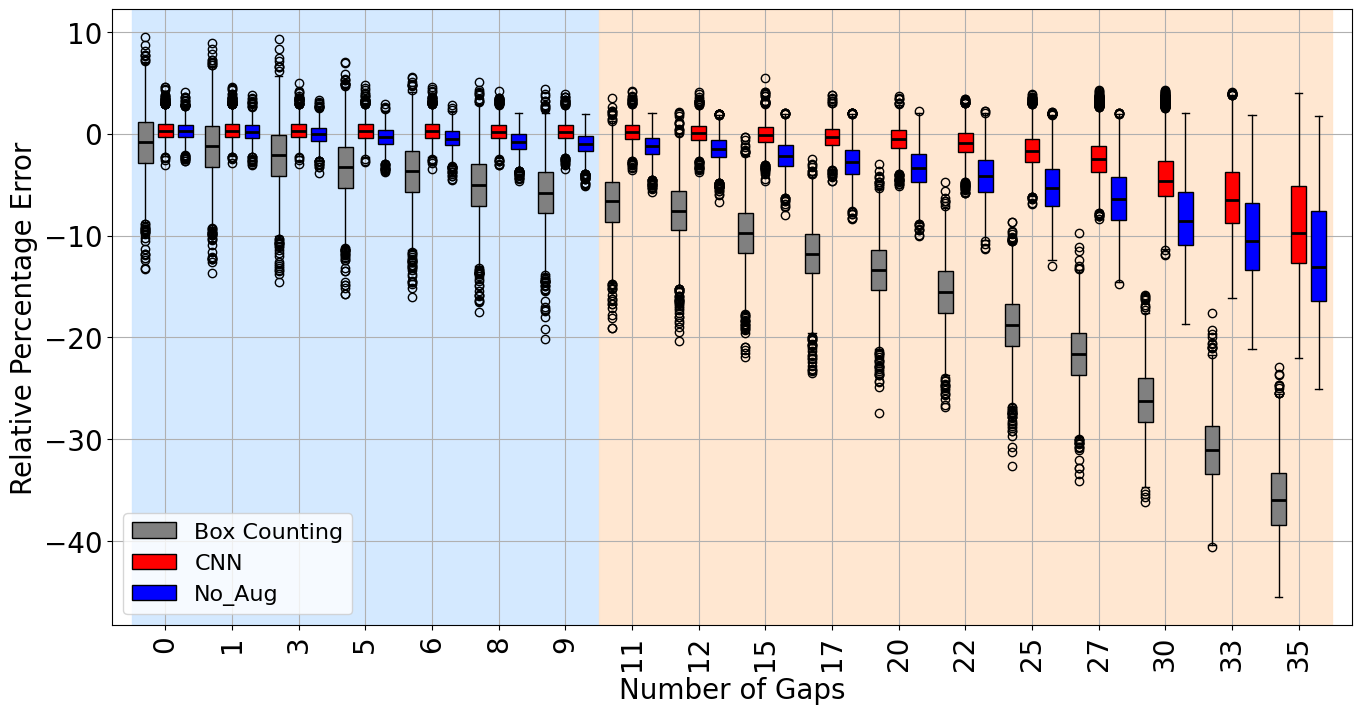

In [6]:
%matplotlib inline

porzione = [0, 1, 3, 5, 6, 8, 9, 11, 12, 15, 17, 20, 22, 25, 27, 30, 33, 35]

cols = [f"Errore_{k}" for k in range(18)]

data_Box = [test_Box[col].dropna().values for col in cols]
data_Rete = [test_Rete[col].dropna().values for col in cols]
data_No = [test_No[col].dropna().values for col in cols]

soglia = 7

fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(1, 19)

# offset to avoid overlap
offset = 0.3

bp1 = ax.boxplot(data_Box, positions=x - offset, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="grey"), medianprops=dict(color="black", linewidth=2))
bp2 = ax.boxplot(data_Rete, positions=x, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="red"), medianprops=dict(color="black", linewidth=2))
bp3 = ax.boxplot(data_No, positions=x + offset, widths=0.22,
                 patch_artist=True, boxprops=dict(facecolor="blue"), medianprops=dict(color="black", linewidth=2))

ax.axvspan(0.5, soglia + 0.5, color="#d0e7ff", alpha=0.9)
ax.axvspan(soglia + 0.5, len(x) + 0.5, color="#ffe5cc", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(porzione, rotation =90)
ax.tick_params(axis='both', labelsize=20)

ax.set_xlabel("Number of Gaps", fontsize=20)
ax.set_ylabel("Relative Percentage Error", fontsize=20)
ax.grid(True)


ax.legend([bp1["boxes"][0], bp2["boxes"][0],bp3["boxes"][0]],
          ["Box Counting", "CNN", "No_Aug"], loc="lower left", fontsize=16)

plt.show()
